In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.environ["DMRGROOT"]) # add the library via environmental variable
# you have to install the dmrgpy library from
# https://github.com/joselado/dmrgpy
# and add its address to your python path (done above with an environmental variable)

# some default parameters in matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['font.size'] = 22
plt.rcParams['image.cmap'] = 'coolwarm'


import numpy as np

# Advanced Quantum Materials, session 7: Quantum entanglement and tensor networks
In this session we will address systems showing entangled group states, and how they can be solved with tensor networks

### Contents
- The system size scaling of tensor networks
- Entanglement entropy in tensor networks

### Learning outcomes
- Rationalize the role of entanglement in ground state
- Understand the ability of tensor networks to parameterize many-body wavefunctions

### How the exercises are organized
- (Remider): These are introductory exercises. You can skip them if you feel comfortable with basics of the topic
- (Exercise): Conventional exercise
- Quiz: short questions to answer, for Exercise or Reminder

### It is not necessary to complete all the exercises, you can just focus on those that sound most interesting for you.

## (Exercise) Energy of the Heisenberg model as a function of the system size
Let us first look at the many-body energy of the Heisenberg model as function of the system size

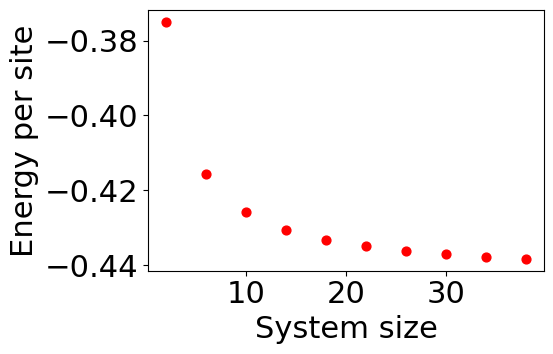

In [2]:
from dmrgpy import spinchain

def get_energy(N):
    """Return energies for a system fo size N"""
    spins = ["S=1/2" for i in range(N)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = 1. # exchange coupling
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    return sc.gs_energy(mode="DMRG")/N # energy per site

plt.figure(figsize=(6,4))

Ns = [i for i in range(2,40,4)] # lengths of the system
es = [get_energy(N) for N in Ns] # ground state energy per site

plt.scatter(Ns,es,s=40,c="red") # plot the energies

plt.xlabel("System size") ; plt.ylabel("Energy per site") ;  plt.tight_layout()

### Quiz
- Why does the energy per site depend on the system size
- What would be the value in the thermodynamic limit?
- What is the biggest system that you could compute with exact diagonalization?

## (Exercise) Near lineal scaling with system size with matrix product states
We now show that matrix product states allow computing the ground state with a complexity that is linear with the system size

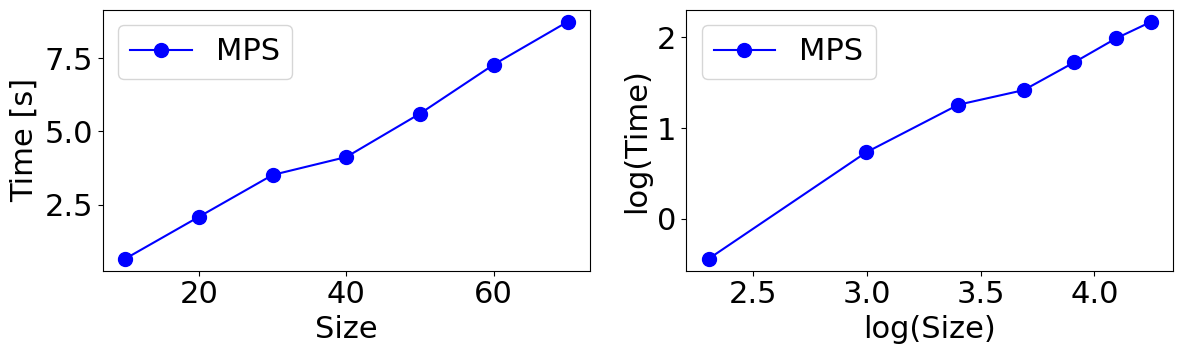

In [3]:
from dmrgpy import spinchain

def get_times(N):
    """Return time srequired for the calculation with ED and MPS"""
    spins = ["S=1/2" for i in range(N)] # S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = 1. # exchange coupling
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + J*sc.Sx[i]*sc.Sx[i+1] ; h = h + J*sc.Sy[i]*sc.Sy[i+1] ; h = h + J*sc.Sz[i]*sc.Sz[i+1]
    import time
    sc.set_hamiltonian(h) # set the Hamiltonian
    t0mps = time.time() # initial time for MPS
    sc.maxm = 20 # not large bond dimension
    sc.get_gs(mode="DMRG") # compute ground state
    t1mps = time.time() # initial time for MPS
    return t1mps-t0mps # return MPS times

plt.figure(figsize=(12,4))

Ns = [i for i in range(10,80,10)] # lengths of the system
tsmps = [get_times(N) for N in Ns] # computational times

plt.subplot(1,2,1)
plt.plot(Ns,tsmps,markersize=10,c="blue",label="MPS",marker="o") # plot the MPS times
plt.xlabel("Size") ; plt.ylabel("Time [s]")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.log(Ns),np.log(tsmps),markersize=10,c="blue",label="MPS",marker="o") # plot the MPS times
plt.xlabel("log(Size)") ; plt.ylabel("log(Time)")
plt.legend()

plt.tight_layout()

### Quiz
- Why is the scaling linear with the system size if the Hilbert space has exponential dimension?
- How can you know that the ground state you got is accurate, and can you quantify this somehow?

## (Exercise) The role of the bond dimension in tensor networks
We will now see that the bond dimension control the accuracy of the calculation, by computing the fluctuation of the energy per site

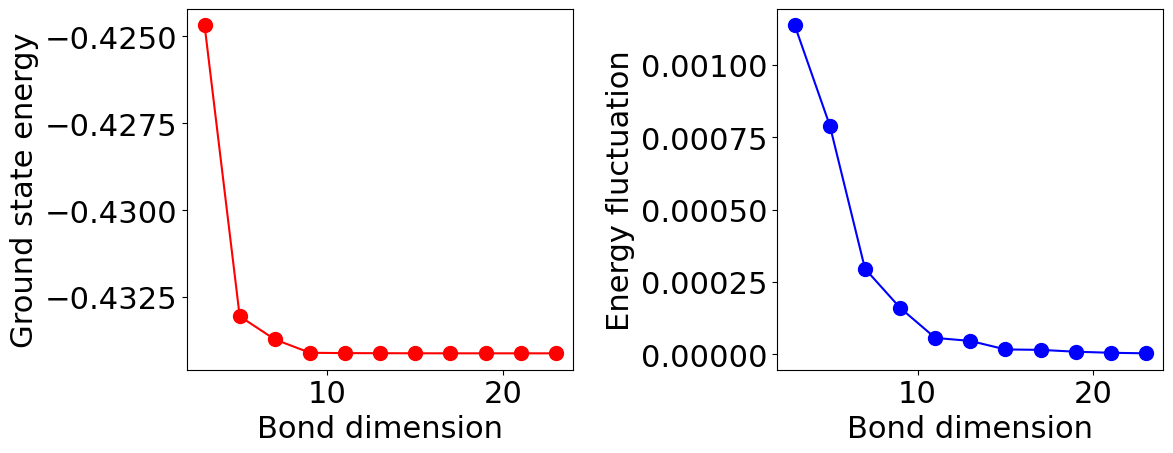

In [4]:
from dmrgpy import spinchain
import numpy as np
n= 20 # size of the chain
spins = ["S=1/2" for i in range(n)] # S=1/2 chain
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1):
    h = h + sc.Sx[i]*sc.Sx[i+1]
    h = h + sc.Sy[i]*sc.Sy[i+1]
    h = h + sc.Sz[i]*sc.Sz[i+1]
bds = range(3,24,2) # bond dimension
es,des = [],[] # storage of energies and fluctuations
for maxm in bds: # loop over bond dimension
    sc.set_hamiltonian(h) # create the Hamiltonian
    sc.maxm = maxm # set the bond dimension
    e = sc.gs_energy() # get the ground state energy
    wf = sc.get_gs() ; de = wf.dot(h*(h*wf)) # Energy square
    de = np.sqrt(np.abs(de-e**2)) # energy fluctuation
    es.append(e/n) # store energy
    des.append(de/n) # energy fluctuation
    
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(bds,es,c="red",marker="o",markersize=10)
plt.ylabel("Ground state energy")
plt.xlabel("Bond dimension")

plt.subplot(1,2,2)
plt.plot(bds,des,c="blue",marker="o",markersize=10)
plt.ylabel("Energy fluctuation")
plt.xlabel("Bond dimension")

plt.tight_layout()
plt.show()

### Quiz
- Which value of the bond dimension is enough to get an accurate ground state?
- What does it mean the energy of the fluctuation of the ground state?
- Make the system bigger, how do the previous plots behave, and why?

## (Exercise) Low energy excitations of a Heisenberg model
We will now see what are the matrix elements between the ground state and the first excited state in a Heisenberg model

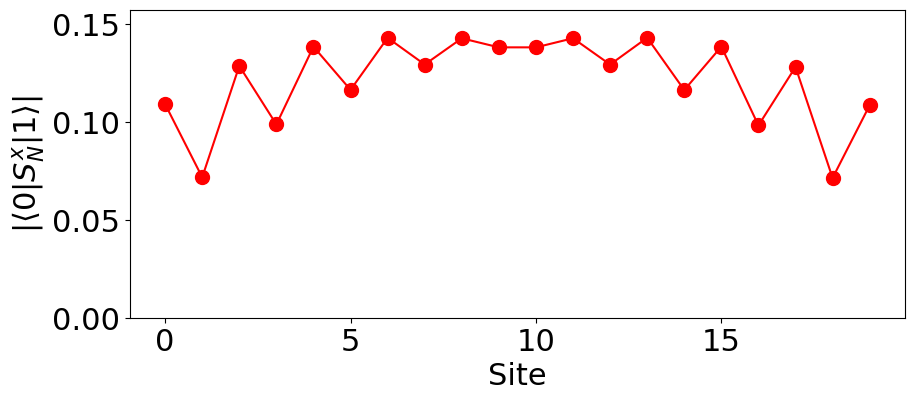

In [6]:
from dmrgpy import spinchain

L = 20 # number of spins
spins = ["S=1/2" for i in range(L)] # four S=1/2 in each site
sc = spinchain.Spin_Chain(spins) # create spin chain object
h = 0 # initialize Hamiltonian
for i in range(len(spins)-1): # Heisenberg coupling
    h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
Bz = 0.03 # small magnetic field
for i in range(len(spins)): h = h + Bz*sc.Sz[i] # and lets add a small magnetic field
sc.set_hamiltonian(h) # set the Hamiltonian

es,wfs = sc.get_excited_states(mode="DMRG",n=2)
wf0,wf1 = wfs[0],wfs[1] # lowest and first excited state


cs = [wf1.dot(sc.Sx[i]*wf0) for i in range(L)] # matrix elements between ground state and excited state

plt.figure(figsize=(10,4))
plt.plot(range(L),np.abs(cs),markersize=10,c="red",marker="o")
plt.xlabel("Site") ; plt.ylabel("$|\\langle 0|S^x_N|1\\rangle |$")
plt.ylim([0,max(np.abs(cs))*1.1])
plt.show()

### Quiz
- What is the physical interpretation of the previous profile?
- Why does the profile have a minimum at the edges and a maximum at the center?
- Make the system smaller, what happens?

## (Exercise) Entanglement entropy of the ground state
We will now see how the entanglement entropy in each bond of the variational state depends on the bond dimension

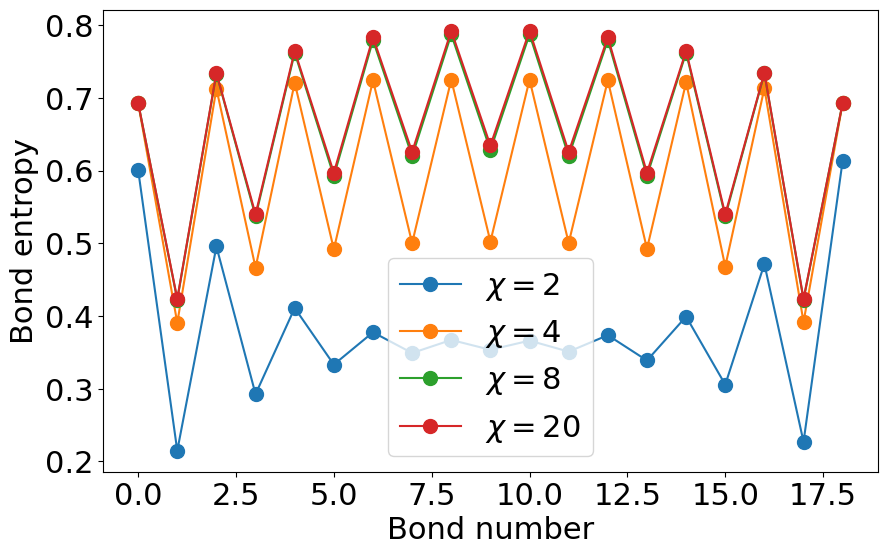

In [8]:
from dmrgpy import spinchain

def get_bond_entropies(maxm):
    L = 20 # 20 spins
    spins = ["S=1/2" for i in range(L)] # four S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    sc.maxm = maxm # set the bond dimension
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG")
    return [wf0.get_bond_entropy(i-1,i) for i in range(1,L)]

plt.figure(figsize=(10,6))

for maxm in [2,4,8,20]:
    cs = get_bond_entropies(maxm) # matrix elements between ground state and excited state
    plt.plot(range(len(cs)),cs,markersize=10,marker="o",label="$\chi = $"+str(maxm))
    plt.xlabel("Bond number") ; plt.ylabel("Bond entropy")

plt.legend()

### Quiz
- Why does the entanglement entropy saturate with the bond dimension?
- Make the system bigger, how does the previous plot change, and why?
- What is the meaning of the bond entanglement entropy?
- Replace the Heisenberg model by an Ising model, how does the entanglement entropy change, and why?

## (Exercise) Size dependence of the entanglement entropy
We will now see that for a one dimensional system the entaglement entropy has a weak system size dependence

(0.0, 0.9776111297210376)

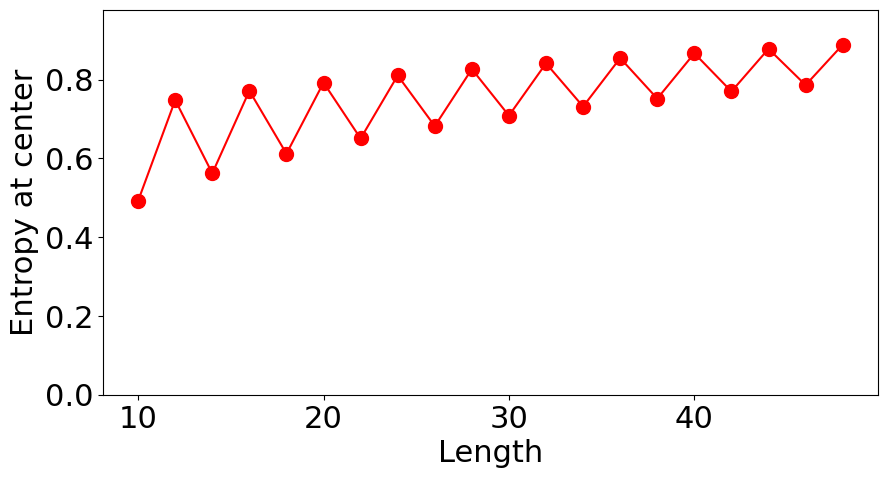

In [9]:
from dmrgpy import spinchain

def get_entropy(L=20):
    spins = ["S=1/2" for i in range(L)] # four S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = -1 # exchange
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG") # get ground state
    return wf0.get_bond_entropy(L//2,L//2+1)

Ls = range(10,50,2) # lengths
Ss = [get_entropy(L=L) for L in Ls] # entropies

plt.figure(figsize=(10,5))
plt.plot(Ls,Ss,markersize=10,marker="o",c="red")
plt.xlabel("Length") ; plt.ylabel("Entropy at center") ; plt.ylim([0,max(Ss)*1.1])



### Quiz
- Why does the entanglement entropy grow so slowly?
- Could you modify the Hamiltonian so that the growth is even slower, and if so, how?

## (Exercise) Bond dimension dependence of the entanglement entropy
We will now see how the entanglement entropy of a many-body state depends on the bond dimension of the matrix product state

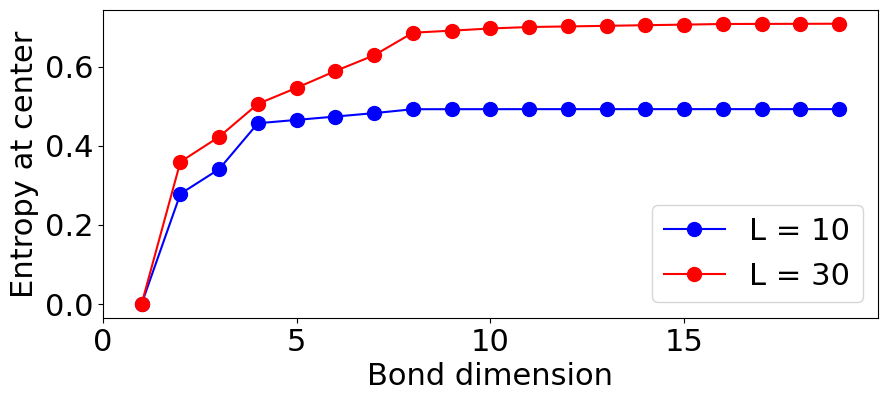

In [11]:
from dmrgpy import spinchain

def get_entropy(maxm=10,L=10):
    spins = ["S=1/2" for i in range(L)] # four S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = -1 # exchange
    for i in range(len(spins)-1): # Heisenberg coupling
        h = h + sc.Sx[i]*sc.Sx[i+1] ; h = h + sc.Sy[i]*sc.Sy[i+1] ; h = h + sc.Sz[i]*sc.Sz[i+1]
    sc.set_hamiltonian(h) # set the Hamiltonian
    sc.maxm = maxm
    wf0 = sc.get_gs(mode="DMRG") # get ground state
    return wf0.get_bond_entropy(L//2,L//2+1)

ms = range(1,20,1) # lengths
Ss0 = [get_entropy(maxm=m,L=10) for m in ms] # entropies
Ss1 = [get_entropy(maxm=m,L=30) for m in ms] # entropies

plt.figure(figsize=(10,4))
plt.plot(ms,Ss0,markersize=10,marker="o",c="blue",label="L = 10")
plt.plot(ms,Ss1,markersize=10,marker="o",c="red",label="L = 30")
plt.xlabel("Bond dimension") ; plt.ylabel("Entropy at center") ; plt.xlim([0,20]) ; plt.xticks(range(0,20,5))
plt.legend()


### Quiz
- Which ground state is more accurate at bond dimension 5?
- Make the system bigger, when does the entropy saturate and why?
- Remove the XX and YY couplings, what happens and why?

## (Exercise) The entanglement entropy as a signal for phase transitions
Let us now see that the entanglement entropy can be used to detect a quantum phase transition, in particular for the transverse field Ising model

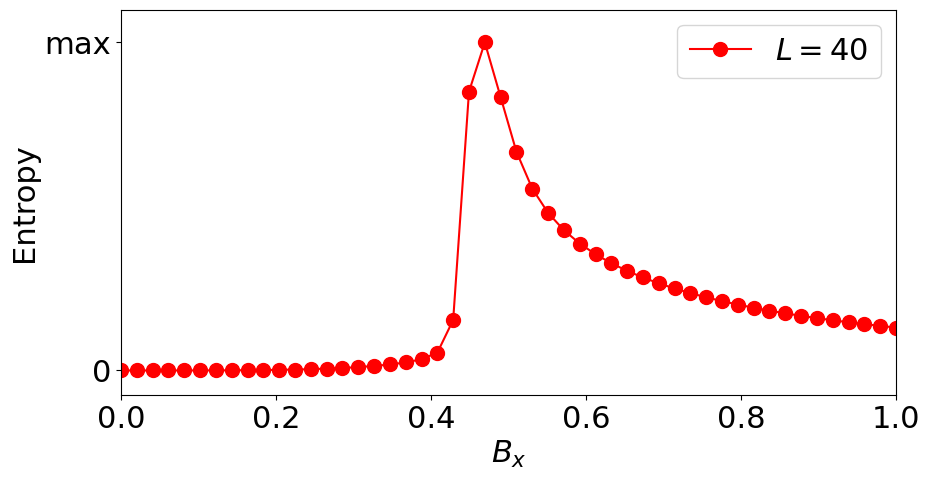

In [12]:
from dmrgpy import spinchain

def get_entropy(L=20,Bx=0.):
    spins = ["S=1/2" for i in range(L)] # four S=1/2 in each site
    sc = spinchain.Spin_Chain(spins) # create spin chain object
    h = 0 # initialize Hamiltonian
    J = -1 # exchange
    for i in range(len(spins)-1): h = h + J*sc.Sz[i]*sc.Sz[i+1] # Ising coupling
    for i in range(L): h = h + Bx*sc.Sx[i] # tranverse field
    sc.set_hamiltonian(-sum(sc.Sz)) ; wfguess = sc.get_gs(mode="DMRG") # get a full ferro state
    sc.set_hamiltonian(h) # set the Hamiltonian
    wf0 = sc.get_gs(mode="DMRG",wf0=wfguess) # get ground state
    return wf0.get_bond_entropy(L//2,L//2+1)

plt.figure(figsize=(10,5))

Bxs = np.linspace(0.,1.,50,endpoint=True)
L = 40 # length of the system
ent = [get_entropy(L=L,Bx=Bx) for Bx in Bxs]
plt.plot(Bxs,ent,markersize=10,marker="o",label="$L = $"+str(L),c="red")
plt.xlabel("$B_x$") ; plt.ylabel("Entropy") ; plt.xlim([min(Bxs),max(Bxs)]) ; plt.ylim([-0.05,max(ent)*1.1])
plt.yticks(ticks=[0,max(ent)],labels=["0","max"])

plt.legend()

### Quiz
- Where do you think that the phase transition is in the thermodynamic limit?
- Why is the entanglement entropy small for small Bx and large Bx?
- Make the system smaller, what happens and why?
- Which region is the hardest to capture with matrix product states?